# Quantum error correction

The power of quantum computing comes from generalising the notion of a classical bit to a _qubit_. A classical bit is a system with a binary attribute, such as a light switch that is either off (0) or on (1). At any given time, the system occupies exactly one of the two states, 0 or 1. 

A qubit differs crucially from a classical bit. It is not a piece of information that lives in a discrete state 0 or 1, but one that can exist as a linear combination of the two states and only under measurement does in live in one of the states 0 or 1. In particular, a qubit is a physical system with a measurement operator such that the following hold:
- Prior to measurement the state of the system can be represented by a unit vector in two-dimensional complex space.
- When measured the system yields one of two binary outcomes.

Note from a mathematical point of view, a classical bit is simply a special case of a qubit that is always confined to the states 0 and 1.

<details style="border:2px solid #7c3aed; border-radius:8px; max-width:95%; margin:auto; overflow:hidden;">

<summary style="padding:8px 12px; cursor:pointer;">
Example. Spin states.
</summary>

<div style="background: display:flex; justify-content:center;">

<div style="max-width:95%; line-height:1.6; padding:12px;">

The Stern-Gerlach experiment passes atoms through a special magnetic field and their resulting positions detected on a screen. The atoms accumulate in exactly two distinct locations, conventionally referred to as _spin up_ and _spin down_. That is, after measurement the experiment has two possible outcomes. Therefore, this system appears to be analogous to a classical bit. However, there is one fundamental difference.

The crucial difference between a bit and a qubit is what happens _before_ measurement. In the classical situation, the light switch is always either on or off even when it is unobserved. In contrast, prior to being detected on the screen, an atom is not necessarily in a _spin up_ or _spin down_ state. Instead, it is in a state that combines both possibilities and only upon measurement does the atom collapse to one of the two outcomes. More precisely, it is a linear combination of the two states spin up and spin down. Mathematically, this is notion is familiar: a state is a vector. In particular, the state is a directional vector in three-dimensional space. Interactions with other physical objects, like the electromagnetic fields, change this state continuously, for example by rotating it. But it's value is not known until it is measured.

</div>
</details>

## Modelling quantum states

Quantum systems are modelled using a Hilbert space $H$. In the finite dimensional case, a Hilbert space is simply a complex inner product space. In an $n$-dimensional Hilbert space $H$, for vectors 
$$u = (u_1,u_2,\dots,u_n) \;\; \text{ and } \;\; v=(v_1,v_2,\dots,v_n),$$
the inner product is defined by
$$\langle u \vert v \rangle = \sum_{i=1}^n u_i^\ast v_i$$
where $\ast$ denotes complex conjugation.

If we view column vectors as matrices of dimension $n \times 1$, this inner product can be written using matrix multiplication as
$$ \langle u \vert v \rangle = (u^\ast)^T v$$
where $T$ denotes matrix transposition. The conjugate transpose of a matrix $M$ is denoted by $M^\dagger = (M^\ast)^T$.

This notation leads to the bra ket formalism used in quantum mechanices. For a vector $u \in H$, the ket $\lvert u \rangle$ denotes the corresponding column vector, while the bra $\langle u \rvert$ denotes its conjugate transpose, that is $\langle u \rvert = u^\dagger$. With this notation the inner product becomes matrix multiplication
$$ \langle u \vert v \rangle = \langle u \rvert \lvert v \rangle.$$

A bra $\langle u \rvert$ is a $1 \times n$ matrix and a ket $\lvert v \rangle$ is a $n \times 1$ matrix. Therefore, the product $\lvert v \rangle \langle u \rvert$ is also well defined, it is an $n \times n$ matrix with entries
$$\lvert v \rangle \langle u \rvert = (v_i u_j^\ast)_{i,j \in [n]}.$$

#### Unitary operations

<div style="border:2px solid #22c55e; border-radius:8px; max-width:95%; margin:auto; overflow:hidden;">

<div style="padding:8px 12px; cursor:pointer;">
Lemma.
</div>

<div style="padding:12px; line-height:1.6;">

Each eigenvalue of a unitary matrix has modulus $1$. Moreover, distinct eigenvalues of a unitary matrix have orthogonal eigenvectors.

</div>
</div>

<details style="border:2px solid #86efac; border-radius:8px; max-width:95%; margin:auto; overflow:hidden;">

<summary style="padding:8px 12px; cursor:pointer; font-style:italic;">
Proof.
</summary>

<div style="padding:12px; line-height:1.6;">

Let $U$ be a unitary matrix. Let $v$ and $w$ be non-zero complex vectors with complex numbers $\lambda$ and $\mu$ such that
$$ Uv = \lambda v \;\; \text{ and } \;\; Uw = \mu w. $$
Since $U$ is a unitary matrix it preserves inner products and we have
$$ \langle v \mid w \rangle = \langle Uv \mid Uw \rangle = \langle \lambda v \mid \mu w \rangle = \lambda^\ast \mu \langle v \mid w \rangle.$$
Solving this equation we obtain that either
$$ \lambda^\ast \mu = 1 \;\; \text{ or } \;\; \langle v \mid w \rangle = 0.$$

We can apply these equations to a single pair $\lambda$ and $v$. Since $v$ is non-zero, it follows that $\lambda^\ast \lambda = 1$, and so, $\lambda$ has modulus $1$. In particular, every eigenvalue of $U$ has modulus $1$. 

Since all eigenvalues have modulus $1$, the condition
$$ \lambda^\ast \mu = 1 $$
is equivalent to
$$ \mu = \lambda. $$
Therefore, if $\lambda \neq \mu$ it follows that $\langle v \mid w \rangle = 0$, and so, $v$ and $w$ are perpendicular. In particular, distinct eigenvalues of a unitary matrix have perpendicular eigenvectors.

</div>
</details>

#### Quantum errors



Qubits are much more fragile than classical bits, so quantum computers are significantly more susceptible to errors. To be able to use them reliably we need methods to detect and correct these errors.

One type of error that can occur is a unitary error, where a qubit is tranformed by a unitary operator during transmission. A basic example is the Pauli $X$ operator
$$X = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}.$$
This operator swaps $\lvert 0 \rangle$ and $\lvert 1 \rangle$. In particular, the $X$ error is a bit-flip; the main error considered in classical error correction. 

The idea of classical error correction was to protect a bit by adding redundancy. The simplest example of this was via the repetition code where we send multiple copies of our bit. For example, in the length $3$ repetition code we would encode
$$ 0 \to 000 \text{ and } 1 \to 111.$$
This allows for some error detection and correction via majority voting. Recall that when we receive three bits we assume the most common one would be the intended message since then fewer errors occured. Ideally we might like to do this for qubits. However, we immediately run into a problem; we cannot copy qubits.

<div style="border:2px solid #22c55e; border-radius:8px; max-width:95%; margin:auto;">

<div style="padding:8px 12px;">
Theorem. [No Cloning Theorem]
</div>

<div style="padding:12px; line-height:1.6;">

Let $H$ be a Hilbert space of dimension greater than $1$. There does not exist a state $\lvert s \rangle$ in $H$ and a unitary operator 
$$U \colon H \otimes H \to H \otimes H$$
such that for all states $\lvert \psi \rangle$ we have
$$U(\lvert \psi \rangle \otimes \lvert s \rangle) = \lvert \psi \rangle \otimes \lvert \psi \rangle.$$

</div>
</div>

<details style="border:2px solid #86efac; border-radius:8px; max-width:95%; margin:auto; overflow:hidden;">

<summary style="padding:8px 12px; cursor:pointer; font-style:italic;">
Proof.
</summary>

<div style="padding:12px; line-height:1.6;">

Assume for contradiction that there exists such a fixed state $\vert s \rangle$ and unitary operator 
$$U \colon H \otimes H \to H \otimes H$$
that clones every state. Then for states $\lvert \psi \rangle$ and $\lvert \phi \rangle$ in $H$. Then there exist phases $\alpha$ and $\beta$ such that
$$ U \lvert \psi \otimes s \rangle = e^{i\alpha} \lvert \psi \otimes \psi \rangle \;\; \text{ and } \;\; U \lvert \phi \otimes s \rangle = e^{i\beta} \lvert \phi \otimes \phi \rangle.$$
Consider the inner product of these two equations. 

On the left hand side we obtain an inner product
$$\langle U(\psi \otimes s) \mid U(\phi \otimes s) \rangle = \langle \psi \otimes s \rvert U^\dagger U \lvert \phi \otimes s \rangle.$$
Since $U$ is unitary we have that $U^\dagger U = \mathrm{Id}$ we can simplify this to obtain 
$$\langle \psi \otimes s \rvert U^\dagger U \lvert \phi \otimes s \rangle = \langle \psi \otimes s \mid \phi \otimes s \rangle = \langle \psi \mid \phi \rangle \langle s \mid s \rangle = \langle \psi \mid \phi \rangle.$$

On the right hand side we obtain an inner product
$$ \langle e^{i\alpha} \psi \otimes \psi \mid e^{i\beta} \phi \otimes \phi \rangle = e^{-i(\alpha-\beta)} \langle \psi \mid \phi \rangle^2.$$

Thus comparing the left and right hand side we obtain an equality
$$\langle \psi \mid \phi \rangle = e^{-i(\alpha-\beta)} \langle \psi \mid \phi \rangle^2.$$
In particular, either
$$ \langle \psi \mid \phi \rangle = 0 \;\; \text{ or } \;\; \lvert \langle \psi \mid \phi \rangle \rvert = 1.$$

Moreover, since $H$ is at least two dimensional, there exists a state $\varphi$ that is perpendicular to $\phi$. Let 
$$\psi = \frac{1}{\sqrt{2}} \lvert \varphi \rangle + \frac{1}{\sqrt{2}} \lvert \phi \rangle.$$
Then we have
$$\langle \psi \mid \phi \rangle = \frac{1}{\sqrt{2}} \left(\langle \varphi \mid \phi \rangle + \langle \phi \mid \phi \rangle\right) = \frac{1}{\sqrt{2}}.$$
Thus, we have a contradiction
$$\frac{1}{\sqrt{2}} = \lvert \langle \psi \mid \phi \rangle \rvert = 1.$$

</div>
</details>

Instead we need a different approach. We cannot copy an unknown quantum state directly, but we can spread the information by creating an entangled state.
In particular, for a qubit 
$$\lvert \psi \rangle = \alpha \lvert 0 \rangle + \beta \lvert 1 \rangle,$$
we introduce two ancilla qubits 
$$\lvert \psi \rangle \otimes \lvert 00 \rangle = \alpha \lvert 000 \rangle + \beta \lvert 100 \rangle.$$
Applying CNOT gates, one from the first qubit to the second, and one from the first qubit to the third we obtain the state
$$\alpha \lvert 000 \rangle + \beta \lvert 111 \rangle.$$
Thus we have added redundancy to our qubit as in the classical case. Note this does not violate the no cloning theorem because we have not created an independent copy of $\lvert \psi \rangle$; instead the state is entangled across three qubits.

We can create this circuit using qiskit as follows.

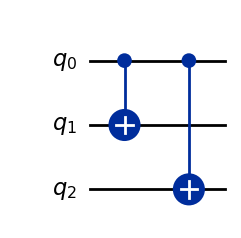

In [10]:
from qiskit import QuantumCircuit, QuantumRegister

qc = QuantumCircuit(3)
qc.cx(0, 1)
qc.cx(0, 2)
qc.draw("mpl")

Now we can use similar logic to the classical case to detect bit flip errors. Suppose there is a bit flip on the first qubit. Then the received state is
$$\alpha \lvert 100 \rangle + \beta \lvert 011 \rangle.$$
In the classical case, to detect whether an error has occured we would inspect the value of each bit to compute the majority value. We cannot do this with qubits, since measuring each of the qubits would collapse the superposition and destroy the information we wish to protect. Instead, we can extract the information indirectly using parity checks.

Recall that the repetition code on three bits is an $[3,1,3]$ code and so it has $3-1=2$ linearly independennt parity checks. Two possible parity checks are 
$$ v_1 + v_2 = 0 \;\; \text{ and } \;\; v_2 + v_3 = 0.$$
We can evaluate these parity checks on our qubit using CNOT gates with two extra ancilla qubits initialised in $\vert 00 \rangle$. The first ancilla qubit will store the value of the first parity check and the second will store the value of the second parity check.

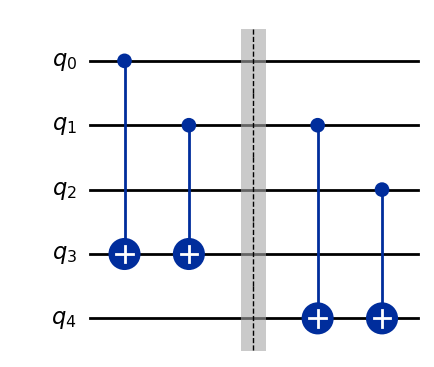

In [11]:
from qiskit import QuantumCircuit, QuantumRegister

qc_bit_flip = QuantumCircuit(5)

qc_bit_flip.cx(0,3)
qc_bit_flip.cx(1,3)

qc_bit_flip.barrier()

qc_bit_flip.cx(1,4)
qc_bit_flip.cx(2,4)

qc_bit_flip.draw("mpl")


We can compute this circuit explicitly starting with our state 
$$\alpha \lvert 100 \rangle \otimes \lvert 00 \rangle + \beta \lvert 011 \rangle \otimes \lvert 00 \rangle.$$
After applying the first parity check $v_1+v_2$ we obtain
$$\alpha \lvert 100 \rangle \otimes \lvert 10 \rangle + \beta \lvert 011 \rangle \otimes \lvert 10 \rangle.$$
Now applying the second parity check $v_2+v_3$ we obtain
$$\alpha \lvert 100 \rangle \otimes \lvert 10 \rangle + \beta \lvert 011 \rangle \otimes \lvert 10 \rangle.$$
The two ancilla qubits store the syndrome $\lvert 10 \rangle$.

We can apply this process to all single bit flip errors to obtain the following table:
| Error | Received qubit | Syndrome qubits |
| ---   | ---              | ---                      |
| No error | $\alpha \lvert 000 \rangle + \beta \vert 111 \rangle$ | 00 |
| First bit flips | $\alpha \lvert 100 \rangle + \beta \vert 011 \rangle$ | 10 |
| Second bit flips | $\alpha \lvert 010 \rangle + \beta \vert 101 \rangle$ | 11 |
| Third bit flips | $\alpha \lvert 001 \rangle + \beta \vert 110 \rangle$ | 01 |

Notice that the four syndrome qubits are distinct; in fact they are the syndromes given in the classical case! In particular, given each syndrome we can apply a gate to the received qubit to undo the error as follows:

| Error | Syndrome qubits | Fix | 
| ---   | ---              | ---                      |
| No error | 00 | $I \otimes I \otimes I$ |
| First bit flips | 10 | $X \otimes I \otimes I$ |
| Second bit flips | 11 | $I \otimes X \otimes I$ |
| Third bit flips | 01 | $I \otimes I \otimes X$ |

Therefore, we can reliably use the repetition code to reduce the probability of bit flip errors and sometimes correct them. In particular, as we are essentially using the repetition code, which cannot correct for more than one error using syndrome measurements, we can also only correct for one quantum bit flip in this case.


The total circuit for this bit flip error correction is given as follows.

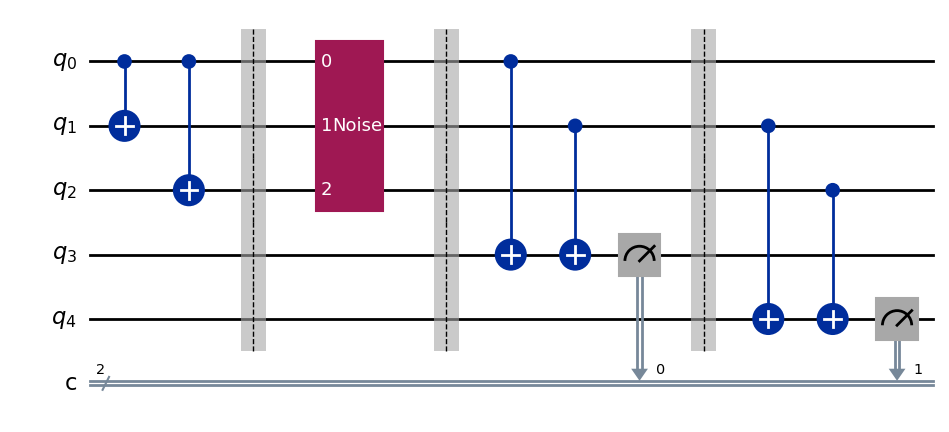

In [12]:
from qiskit import QuantumCircuit
from qiskit.circuit import Gate

qc_bit_flip = QuantumCircuit(5,2)

qc_bit_flip.cx(0, 1)
qc_bit_flip.cx(0, 2)

qc_bit_flip.barrier()

noise = Gate(name="Noise", num_qubits=3, params=[])

qc_bit_flip.append(noise, [0,1,2])

qc_bit_flip.barrier()

qc_bit_flip.cx(0,3)
qc_bit_flip.cx(1,3)

qc_bit_flip.measure(3,0)

qc_bit_flip.barrier()

qc_bit_flip.cx(1,4)
qc_bit_flip.cx(2,4)

qc_bit_flip.measure(4,1)

qc_bit_flip.draw("mpl")
